# 🧠 Neural Networks 101: How Does a Neural Network Work?

## A real world case study--predict the future CO2

**Author:** J. Paul Liu. — NC State University  
**Course:** [Generative AI for Science](https://github.com/jpliu168/Generative_AI_For_Science)

**Date:** Spring-Fall 2026  

**This is an extra, not included in the physical book!**


---

## Notebook Overview

In Neural Networks 101, we learned the fundamental building blocks — neurons, weights, biases, and activation functions. In this notebook, we go deeper by building increasingly complex networks and seeing **why architecture matters.**

We progress through three stages:

| Part | Task | Network | Key Lesson |
|:--:|:---|:---|:---|
| **1** | Linear sequence prediction | 1 hidden layer (16 neurons) | A simple network can learn simple patterns |
| **2** | Nonlinear time series (trend + sinusoid) | 3 hidden layers (16 neurons each) | Complex patterns require deeper networks |
| **3** | Real Mauna Loa CO₂ data | 3 hidden layers (64–32–16 neurons) | Applying neural networks to real-world science |

> 💡 **Key Insight:** A neural network is a *universal function approximator*. Given enough neurons and layers, it can learn virtually any mapping from inputs to outputs. But *how much* capacity you need depends on *how complex* the underlying pattern is.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Build feedforward neural networks of varying depth using PyTorch
- Explain the difference between linear and nonlinear prediction tasks
- Understand why deeper networks are needed for more complex patterns
- Prepare real-world time series data for neural network training
- Train a model on historical CO₂ observations and forecast future values
- Visualize and interpret training loss curves and model predictions

## ⚙️ Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


**What is torch?**

torch is the core PyTorch library.

It provides:

	•	Tensors (like NumPy arrays, but GPU-accelerated)

	•	Math operations

	•	Automatic differentiation (autograd)

	•	Device handling (CPU / GPU)


What you typically use it for
torch.tensor(...)

torch.arange(...)

torch.zeros(...)

torch.matmul(...)

2️⃣ import torch.nn as nn


**What is torch.nn?**

torch.nn is PyTorch’s neural network module.

It contains:

	•	Layers (Linear, Conv2d, LSTM, etc.)

	•	Activation functions (ReLU, Sigmoid)

	•	Loss functions (MSELoss, CrossEntropyLoss)

	•	Model base class (nn.Module)


---
# Part 1: Single Hidden Layer — Linear Sequence Prediction

## The Task

We start with the simplest possible prediction task: **predict the next number in a linear sequence.**

Given a sliding window of 4 consecutive numbers from the sequence `[1, 2, 3, ..., 100]`, the network should predict the next number:

| Input Window | Target |
|:---:|:---:|
| [1, 2, 3, 4] | 5 |
| [2, 3, 4, 5] | 6 |
| [3, 4, 5, 6] | 7 |

This is a **linear** relationship — the step between consecutive numbers is always 1. A single hidden layer should be sufficient to learn this pattern.

BUT, the NN doesn't know our data is a linear relationship!

### Step 1: Prepare the Training Data

We create a sliding window of length 4 over the sequence `[1, 2, 3, ..., 100]`. Each window becomes one training sample, and the number right after the window is the target.

In [ ]:
# Generate a simple linear sequence: 1, 2, 3, ..., 100
sequence = torch.arange(1, 101, dtype=torch.float32) #or int8, boolean

# Sliding window parameters
window_size = 4

X = []
y = []

for i in range(len(sequence) - window_size):
    X.append(sequence[i:i + window_size])     # 4 input numbers
    y.append(sequence[i + window_size])         # target: next number

X = torch.stack(X)                              # shape: (96, 4)
y = torch.tensor(y).unsqueeze(1)                # shape: (96, 1)

print(f"Training samples: {X.shape[0]}")
print(f"Input shape:  {X.shape}   (samples × window_size)")
print(f"Target shape: {y.shape}   (samples × 1)")
print(f"\nExample — Input: {X[0].tolist()} → Target: {y[0].item():.0f}")
print(f"Example — Input: {X[1].tolist()} → Target: {y[1].item():.0f}")

Training samples: 96
Input shape:  torch.Size([96, 4])   (samples × window_size)
Target shape: torch.Size([96, 1])   (samples × 1)

Example — Input: [1.0, 2.0, 3.0, 4.0] → Target: 5
Example — Input: [2.0, 3.0, 4.0, 5.0] → Target: 6


In [ ]:
print(X)
print(y)

tensor([[ 1.,  2.,  3.,  4.],
        [ 2.,  3.,  4.,  5.],
        [ 3.,  4.,  5.,  6.],
        [ 4.,  5.,  6.,  7.],
        [ 5.,  6.,  7.,  8.],
        [ 6.,  7.,  8.,  9.],
        [ 7.,  8.,  9., 10.],
        [ 8.,  9., 10., 11.],
        [ 9., 10., 11., 12.],
        [10., 11., 12., 13.],
        [11., 12., 13., 14.],
        [12., 13., 14., 15.],
        [13., 14., 15., 16.],
        [14., 15., 16., 17.],
        [15., 16., 17., 18.],
        [16., 17., 18., 19.],
        [17., 18., 19., 20.],
        [18., 19., 20., 21.],
        [19., 20., 21., 22.],
        [20., 21., 22., 23.],
        [21., 22., 23., 24.],
        [22., 23., 24., 25.],
        [23., 24., 25., 26.],
        [24., 25., 26., 27.],
        [25., 26., 27., 28.],
        [26., 27., 28., 29.],
        [27., 28., 29., 30.],
        [28., 29., 30., 31.],
        [29., 30., 31., 32.],
        [30., 31., 32., 33.],
        [31., 32., 33., 34.],
        [32., 33., 34., 35.],
        [33., 34., 35., 36.],
        [3

### Step 2: Define the Neural Network

We define a class with:
- **One hidden layer:** 4 inputs → 16 neurons (linear transformation + ReLU activation)
- **One output layer:** 16 neurons → 1 predicted value

## Network Architecture (1 Hidden Layer)

A neural network with one hidden layer computes something like:

$$
y = \sum_{i=1}^{n} v_i \cdot \sigma(w_i x + b_i)
$$

- \(w_i, b_i\): weights into hidden neurons  
- \(\sigma\): activation function (ReLU, sigmoid, etc.)  
- \(v_i\): weights to output


```
                  Input x
             (shape: [batch_size, 4])
      ┌─────────────────────────────────┐
      │   x = [x₁, x₂, x₃, x₄]          │
      └───────────────┬─────────────────┘
                      │
                      ▼
          # -----------------------------
        # Hidden layer (Linear layer)
        # -----------------------------
        # nn.Linear(in_features, out_features)
        #
        # Takes an input tensor of shape:
        #   (batch_size, 4)
        # and transforms it into:
        #   (batch_size, 16)
        #
        # Mathematically:
        #   z = xW + b
        #
        # where W is a learnable weight matrix
        # and b is a learnable bias vector

      ┌─────────────────────────────────┐
      │  Linear Layer (4 → 16)          │
      │  self.hidden = nn.Linear(4, 16) │
      │                                 │
      │  h = W₁x + b₁                   │
      │  W₁ ∈ ℝ^(16×4), b₁ ∈ ℝ^16       │
      └───────────────┬─────────────────┘
          # -----------------------------
        # Activation function
        # -----------------------------
        # ReLU(x) = max(0, x)
        #
        # Why we need this:
        # - Introduces NONLINEARITY
        # - Without it, the entire network would collapse
        #   into a single linear transformation
        #
        # ReLU is:
        # - Simple
        # - Computationally efficient
        # - Widely used in practice
                      │
                      ▼
      ┌─────────────────────────────────┐
      │  ReLU Activation                │
      │  h = max(0, h)  (element-wise)  │
      └───────────────┬─────────────────┘
                      │
                      ▼
      ┌─────────────────────────────────┐
      │  Linear Layer (16 → 1)          │
      │  self.output = nn.Linear(16, 1) │
      │                                 │
      │  ŷ = W₂h + b₂                   │
      │  W₂ ∈ ℝ^(1×16), b₂ ∈ ℝ          │
      └───────────────┬─────────────────┘
                      │
                      ▼
      ┌─────────────────────────────────┐
      │  Output ŷ                       │
      │  (predicted next number)        │
      │  shape: [batch_size, 1]         │
      └─────────────────────────────────┘

        # -----------------------------
        # Output layer
        # -----------------------------
        # Maps the 16 hidden features
        # down to 1 output value
        #
        # Output shape:
        #   (batch_size, 1)
        #
        # This is typically used for regression,
        # so NO activation (like sigmoid) is applied here
        
```

**Why only one hidden layer?**  The network essentially needs to learn: *"the next number = last number + 1."* A single layer with 16 neurons has more than enough capacity.

In [ ]:
class SimpleNN(nn.Module):
    """
    A simple feed-forward neural network with ONE hidden layer.

    Purpose:
    --------
    This network maps an input vector of length 4
    to a single scalar output (1 value).

    Typical use case:
    -----------------
    - Time-series prediction using a sliding window of 4 past values
    - Simple regression problems
    """

    def __init__(self):

        # Initialize the parent class (nn.Module)
        # This is REQUIRED for PyTorch to track parameters and gradients

        super().__init__()


        self.hidden = nn.Linear(4, 16)



        self.act = nn.ReLU()



        self.output = nn.Linear(16, 1)

    def forward(self, x):
        """
        Forward pass: defines HOW data flows through the network.

        This method is called automatically when you run:
            y_pred = model(x)

        Input:
        ------
        x : torch.Tensor
            Shape: (batch_size, 4)

        Output:
        -------
        torch.Tensor
            Shape: (batch_size, 1)
        """

        # Step 1: Linear transformation
        # x → hidden features

        x = self.hidden(x)

        # Step 2: Apply nonlinearity
        # Allows the model to learn complex patterns

        x = self.act(x)


        # Step 3: Final linear mapping
        # Hidden features → prediction

        x = self.output(x)

        return x

model = SimpleNN()
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")
print(f"  hidden: 4×16 weights + 16 biases = {4*16 + 16}")
print(f"  output: 16×1 weights + 1 bias    = {16*1 + 1}")

SimpleNN(
  (hidden): Linear(in_features=4, out_features=16, bias=True)
  (act): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
)

Total trainable parameters: 97
  hidden: 4×16 weights + 16 biases = 80
  output: 16×1 weights + 1 bias    = 17


### Step 3: Train the Network

The training loop repeats four steps each epoch:

1. **Forward pass** — feed all inputs through the network to get predictions
2. **Compute loss** — measure error between predictions and targets using Mean Squared Error (MSE)
3. **Backward pass** — compute gradients via backpropagation
4. **Update weights** — the Adam optimizer adjusts all parameters to reduce the loss

In [ ]:
criterion = nn.MSELoss()                            # loss function
'''
	•	Mean Squared Error (MSE) measures how far predictions are from true values
	•	Commonly used for regression
	•	Penalizes large errors more strongly

    MSE = mean((y_pred − y)²)
'''
optimizer = optim.Adam(model.parameters(), lr=0.01)  # optimizer
'''
	•	Adam is an adaptive gradient-based optimizer
	•	Automatically adjusts learning rates for each parameter
	•	lr=0.01 controls how big each update step is

👉 Purpose: update model weights to reduce loss
'''
epochs = 2000
loss_history = []


#Each epoch: clear old gradients → predict → measure error → compute gradients → update weights → record loss.
for epoch in range(epochs):
    optimizer.zero_grad()          # reset gradients

    y_pred = model(X)              # forward pass
    loss = criterion(y_pred, y)    # compute loss

    loss.backward()                # backward pass
    optimizer.step()               # update weights

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        n = np.random.randint(1, 95)
        # take the first sample as an example
        pred_val = y_pred[n].item()
        true_val = y[n].item()

        print(
            f"Epoch {epoch:4d}/{epochs}  "
            f"Loss: {loss.item():.6f}  "
            f"Predicted: {pred_val:.6f}  "
            f"True: {true_val:.6f}"
             )

print(f"\n✅ Training complete. Final loss: {loss_history[-1]:.8f}")

Epoch    0/2000  Loss: 4154.251465  Predicted: -4.798894  True: 57.000000
Epoch  100/2000  Loss: 0.961776  Predicted: 98.526291  True: 98.000000
Epoch  200/2000  Loss: 0.795114  Predicted: 18.653646  True: 20.000000
Epoch  300/2000  Loss: 0.665924  Predicted: 77.238243  True: 77.000000
Epoch  400/2000  Loss: 0.536959  Predicted: 65.959503  True: 66.000000
Epoch  500/2000  Loss: 0.417916  Predicted: 25.146852  True: 26.000000
Epoch  600/2000  Loss: 0.314302  Predicted: 88.359726  True: 88.000000
Epoch  700/2000  Loss: 0.228469  Predicted: 92.367508  True: 92.000000
Epoch  800/2000  Loss: 0.160472  Predicted: 80.156120  True: 80.000000
Epoch  900/2000  Loss: 0.108839  Predicted: 80.128746  True: 80.000000
Epoch 1000/2000  Loss: 0.071218  Predicted: 93.214073  True: 93.000000
Epoch 1100/2000  Loss: 0.044910  Predicted: 28.740652  True: 29.000000
Epoch 1200/2000  Loss: 0.027262  Predicted: 7.688157  True: 8.000000
Epoch 1300/2000  Loss: 0.015909  Predicted: 26.837679  True: 27.000000
Epoch

**3️⃣ import torch.optim as optim**

What is torch.optim?

torch.optim provides optimization algorithms that update model parameters during training.

These implement:

	•	Gradient descent

	•	Momentum

	•	Adaptive learning rates

Common optimizers:

	•	optim.SGD

	•	optim.Adam

	•	optim.RMSprop


**optimizer = optim.Adam(model.parameters(), lr=0.001)**

👉 optim is used to train the model by adjusting weights.

### Step 4: Visualize Training

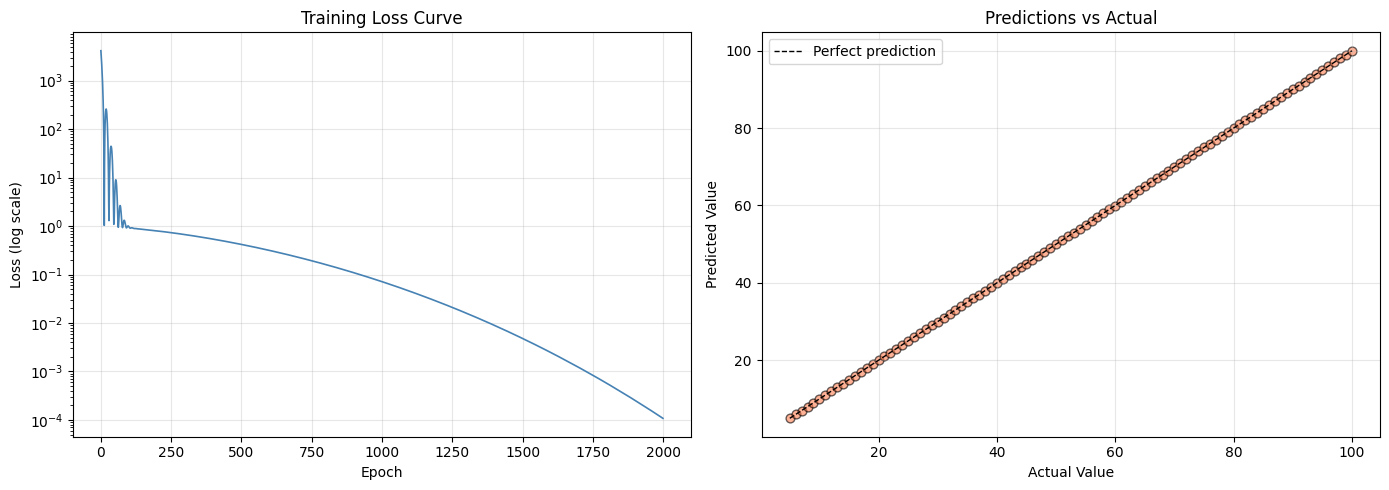

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curve (log scale) ---
axes[0].semilogy(loss_history, color='steelblue', linewidth=1.2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training Loss Curve')
axes[0].grid(True, alpha=0.3)

# --- Predictions vs Actual ---
with torch.no_grad():
    preds = model(X).numpy().flatten()
targets = y.numpy().flatten()

axes[1].scatter(targets, preds, alpha=0.6, color='coral', edgecolors='k', s=40)
axes[1].plot([targets.min(), targets.max()], [targets.min(), targets.max()],
             'k--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel('Actual Value')
axes[1].set_ylabel('Predicted Value')
axes[1].set_title('Predictions vs Actual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 5: Test on Unseen Data

The real test: can the network predict the next number for a window it has **never seen** during training?

In [ ]:
# Test on a sequence near the end of the training range
test_input = torch.tensor([[98, 99, 100, 101]], dtype=torch.float32)

with torch.no_grad():
    prediction = model(test_input)

print(f"Input:     {test_input.tolist()[0]}")
print(f"Predicted: {prediction.item():.2f}")
print(f"Expected:  102")

Input:     [98.0, 99.0, 100.0, 101.0]
Predicted: 102.01
Expected:  102


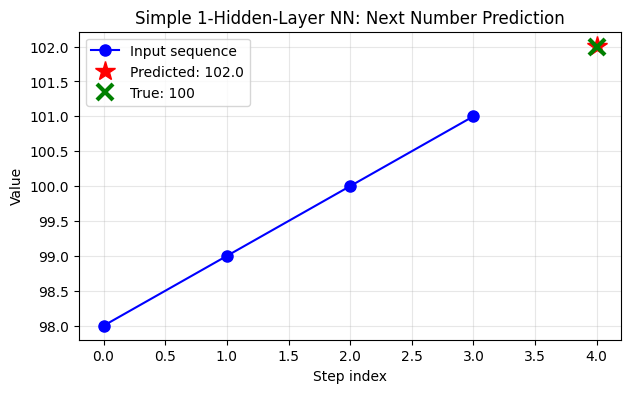

In [ ]:
# Visualize the prediction
x_vals = test_input.numpy().flatten()
y_pred_val = prediction.detach().numpy().flatten()

t_input = np.arange(len(x_vals))
t_pred = len(x_vals)

plt.figure(figsize=(7, 4))
plt.plot(t_input, x_vals, 'bo-', markersize=8, label='Input sequence')
plt.plot(t_pred, y_pred_val, 'r*', markersize=15, label=f'Predicted: {y_pred_val[0]:.1f}')
plt.plot(t_pred, 102, 'gx', markersize=12, mew=3, label='True: 100')
plt.xlabel('Step index')
plt.ylabel('Value')
plt.title('Simple 1-Hidden-Layer NN: Next Number Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### ✅ Part 1 Summary

A single hidden layer with 16 neurons was sufficient to learn the linear pattern `[1, 2, 3, ..., 100]`. The network learned to predict the next number with near-zero error.

> **Question to think about:** What happens if the underlying pattern is *not* linear? Let's find out in Part 2.

---
# Part 2: Three Hidden Layers — Nonlinear Time Series

## Why Go Deeper?

Real-world data is rarely a straight line. Consider a time series that combines a **linear trend** with a **sinusoidal oscillation**:

$$x(t) = 0.05t + \sin(0.2t)$$

This function has:
- A slow upward drift (the `0.05t` term)
- A periodic oscillation (the `sin(0.2t)` term)

The resulting sequence has a **changing, nonlinear pattern** — the step between consecutive numbers is never constant. A single hidden layer may struggle with this.

> 💡 **Intuition:** Think of depth like layers of understanding. Layer 1 might learn basic differences between numbers. Layer 2 might learn how those differences change (acceleration). Layer 3 might learn the overall curvature and periodicity.

## Network Architecture (3 Hidden Layers)

We increase both depth (3 layers) and the input window (8 time steps) to give the network more context for learning the oscillation.

```
                  Input x
             (shape: [batch_size, 8])
      ┌─────────────────────────────────────┐
      │   x = [x₁, x₂, ..., x₈]            │
      │   (8 consecutive time steps)         │
      └─────────────────┬───────────────────┘
                        │
                        ▼
      ┌─────────────────────────────────────┐
      │  Hidden Layer 1 (8 → 16) + ReLU     │
      │  Learns: basic input features        │
      └─────────────────┬───────────────────┘
                        │
                        ▼
      ┌─────────────────────────────────────┐
      │  Hidden Layer 2 (16 → 16) + ReLU    │
      │  Learns: feature combinations        │
      └─────────────────┬───────────────────┘
                        │
                        ▼
      ┌─────────────────────────────────────┐
      │  Hidden Layer 3 (16 → 16) + ReLU    │
      │  Learns: higher-order patterns       │
      └─────────────────┬───────────────────┘
                        │
                        ▼
      ┌─────────────────────────────────────┐
      │  Output Layer (16 → 1)              │
      │  ŷ = predicted next value            │
      └─────────────────────────────────────┘
```

### Step 1: Generate the Nonlinear Time Series

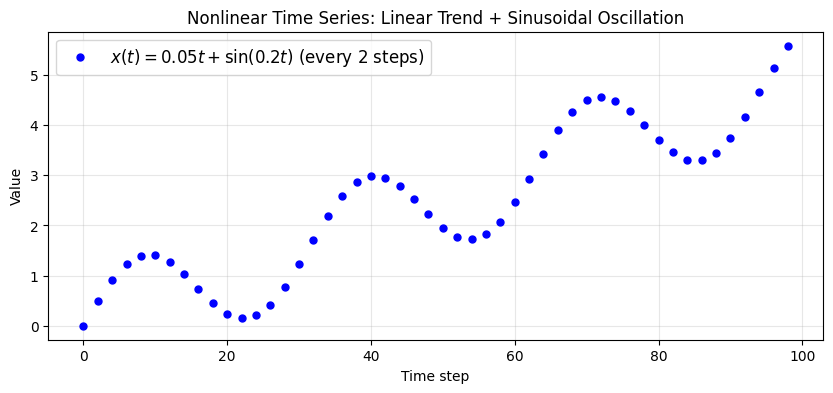

Sequence length: 100
Value range: [0.00, 5.76]


In [ ]:
# Generate nonlinear time series: trend + sinusoid
t = torch.arange(0, 100, dtype=torch.float32)
sequence_nl = 0.05 * t + torch.sin(0.2 * t)

plt.figure(figsize=(10, 4))
#plt.plot(t.numpy(), sequence_nl.numpy(), 'b-', linewidth=1.5, label=r'$x(t) = 0.05t + \sin(0.2t)$')

# Define t_sub and sequence_sub for subsampled plotting
t_sub = t[::2]
sequence_sub = sequence_nl[::2]

# Plot as points instead of line
plt.plot(
    t_sub.numpy(),
    sequence_sub.numpy(),
    'bo',          # blue circles
    markersize=5,
    label=r'$x(t) = 0.05t + \sin(0.2t)$ (every 2 steps)'
)

plt.xlabel('Time step')
plt.ylabel('Value')
plt.title('Nonlinear Time Series: Linear Trend + Sinusoidal Oscillation')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()

print(f"Sequence length: {len(sequence_nl)}")
print(f"Value range: [{sequence_nl.min():.2f}, {sequence_nl.max():.2f}]")

### Step 2: Create Sliding Window Dataset

We use a larger window of 8 time steps. This gives the network enough context to "see" the oscillation pattern.

In [ ]:
window_size = 8

X_nl, y_nl = [], []
for i in range(len(sequence_nl) - window_size):
    X_nl.append(sequence_nl[i:i + window_size])
    y_nl.append(sequence_nl[i + window_size])

X_nl = torch.stack(X_nl)                         # shape: (92, 8)
y_nl = torch.tensor(y_nl).unsqueeze(1)            # shape: (92, 1)

print(f"Training samples: {X_nl.shape[0]}")
print(f"Input shape:  {X_nl.shape}")
print(f"Target shape: {y_nl.shape}")
print(f"\nFirst sample:")
print(f"  Input:  {X_nl[0].numpy().round(3)}")
print(f"  Target: {y_nl[0].item():.3f}")

Training samples: 92
Input shape:  torch.Size([92, 8])
Target shape: torch.Size([92, 1])

First sample:
  Input:  [0.    0.249 0.489 0.715 0.917 1.091 1.232 1.335]
  Target: 1.400


### Step 3: First Attempt — Can 1 Hidden Layer Learn This?

Before building a deeper network, let's see how the simple architecture from Part 1 handles this nonlinear data.

In [ ]:
# Shallow: 1 hidden layer with 16 neurons
class ShallowNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.hidden = nn.Linear(input_size, 16)
        self.act = nn.ReLU()
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = self.act(self.hidden(x))
        x = self.output(x)
        return x

torch.manual_seed(42)
model_shallow = ShallowNN(window_size)
criterion = nn.MSELoss()
optimizer_s = optim.Adam(model_shallow.parameters(), lr=0.001)

# Train for only 500 epochs — a realistic budget
compare_epochs = 3000
losses_shallow = []
for epoch in range(compare_epochs):
    optimizer_s.zero_grad()
    loss_s = criterion(model_shallow(X_nl), y_nl)
    loss_s.backward()
    optimizer_s.step()
    losses_shallow.append(loss_s.item())

print(f'Shallow network — {sum(p.numel() for p in model_shallow.parameters())} params')
print(f'Final loss after {compare_epochs} epochs: {losses_shallow[-1]:.6f}')

Shallow network — 161 params
Final loss after 3000 epochs: 0.002028


### Step 4: Define the 3 Hidden-Layer Network

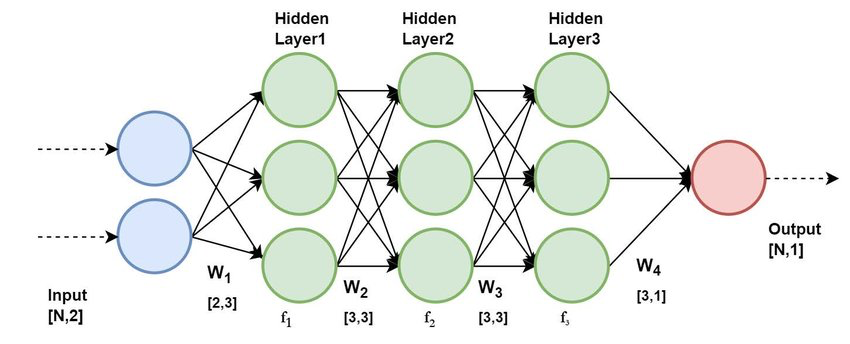

In [ ]:
class DeeperNN(nn.Module):
    """Three hidden-layer network for nonlinear time series prediction."""

    def __init__(self, input_size):
        #input_size
        super().__init__()
        self.hidden1 = nn.Linear(input_size, 16)  # Layer 1
        self.hidden2 = nn.Linear(16, 16)           # Layer 2
        self.hidden3 = nn.Linear(16, 16)           # Layer 3
        self.act     = nn.ReLU()
        self.output  = nn.Linear(16, 1)            # Output

    def forward(self, x):
        x = self.act(self.hidden1(x))
        x = self.act(self.hidden2(x))
        x = self.act(self.hidden3(x))
        x = self.output(x)
        return x

model_deep = DeeperNN(window_size)
print(model_deep)

total_params = sum(p.numel() for p in model_deep.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

DeeperNN(
  (hidden1): Linear(in_features=8, out_features=16, bias=True)
  (hidden2): Linear(in_features=16, out_features=16, bias=True)
  (hidden3): Linear(in_features=16, out_features=16, bias=True)
  (act): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
)

Total trainable parameters: 705


### Step 5: Train the Deep Network

We use more epochs and a smaller learning rate — nonlinear patterns need more careful optimization.

In [ ]:
torch.manual_seed(42)
optimizer_d = optim.Adam(model_deep.parameters(), lr=0.001)

# Same budget: 500 epochs
losses_deep = []

# Prepare a test input for monitoring
t0_test = 80
t_test = torch.arange(t0_test, t0_test + window_size + 1, dtype=torch.float32)
x_test_full = 0.05 * t_test + torch.sin(0.2 * t_test)
test_input_nl = x_test_full[:window_size].unsqueeze(0)
test_truth = x_test_full[window_size].item()

for epoch in range(compare_epochs):
    optimizer_d.zero_grad()
    loss_d = criterion(model_deep(X_nl), y_nl)
    loss_d.backward()
    optimizer_d.step()
    losses_deep.append(loss_d.item())

    if epoch % 100 == 0:
        with torch.no_grad():
            test_pred = model_deep(test_input_nl).item()
        print(f'Epoch {epoch:4d}/{compare_epochs}  Loss: {loss_d.item():.6f}  '
              f'Test pred: {test_pred:.4f}  True: {test_truth:.4f}')

print(f'\nDeep network — {sum(p.numel() for p in model_deep.parameters())} params')
print(f'Final loss after {compare_epochs} epochs: {losses_deep[-1]:.6f}')

Epoch    0/3000  Loss: 8.331106  Test pred: 0.1618  True: 3.4512
Epoch  100/3000  Loss: 0.396158  Test pred: 3.5046  True: 3.4512
Epoch  200/3000  Loss: 0.043719  Test pred: 3.2636  True: 3.4512
Epoch  300/3000  Loss: 0.023602  Test pred: 3.2462  True: 3.4512
Epoch  400/3000  Loss: 0.014484  Test pred: 3.2746  True: 3.4512
Epoch  500/3000  Loss: 0.009016  Test pred: 3.3095  True: 3.4512
Epoch  600/3000  Loss: 0.004324  Test pred: 3.3536  True: 3.4512
Epoch  700/3000  Loss: 0.001371  Test pred: 3.3955  True: 3.4512
Epoch  800/3000  Loss: 0.000349  Test pred: 3.4257  True: 3.4512
Epoch  900/3000  Loss: 0.000111  Test pred: 3.4390  True: 3.4512
Epoch 1000/3000  Loss: 0.000057  Test pred: 3.4463  True: 3.4512
Epoch 1100/3000  Loss: 0.000039  Test pred: 3.4498  True: 3.4512
Epoch 1200/3000  Loss: 0.000031  Test pred: 3.4457  True: 3.4512
Epoch 1300/3000  Loss: 0.000020  Test pred: 3.4477  True: 3.4512
Epoch 1400/3000  Loss: 0.000014  Test pred: 3.4500  True: 3.4512
Epoch 1500/3000  Loss: 0.

### Step 6: Compare Shallow vs Deep Networks

Both networks are trained for the **same number of epochs** (500). With enough training time, both could eventually memorize the data. The question is: **which architecture learns the pattern faster?**

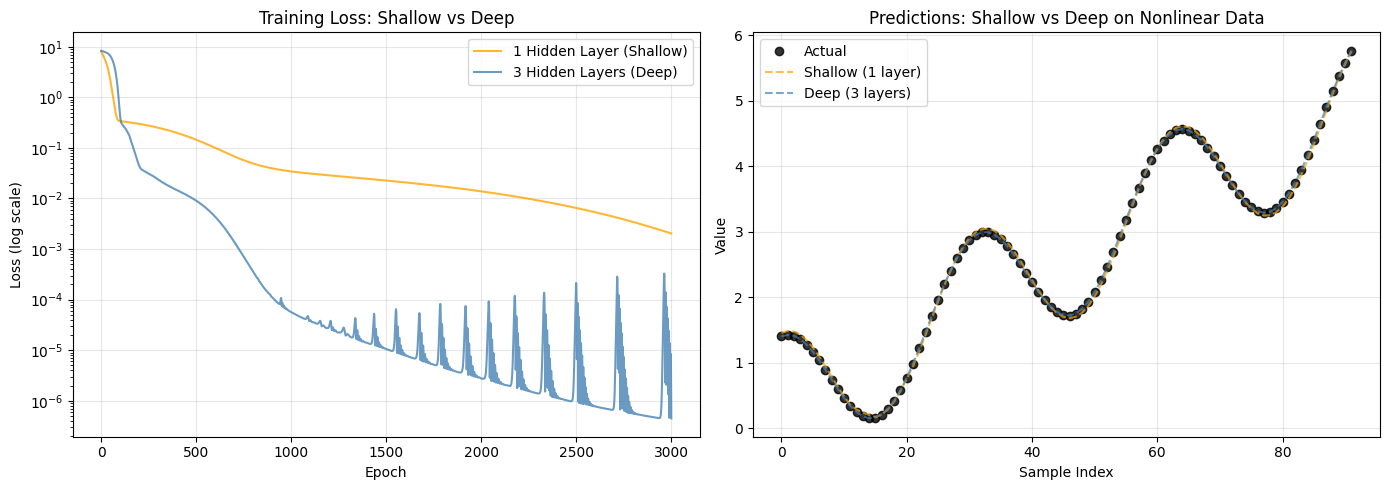

Final loss — Shallow (1 layer): 0.002028
Final loss — Deep (3 layers):   0.000000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss comparison ---
axes[0].semilogy(losses_shallow, label='1 Hidden Layer (Shallow)', color='orange', alpha=0.8)
axes[0].semilogy(losses_deep, label='3 Hidden Layers (Deep)', color='steelblue', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training Loss: Shallow vs Deep')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Prediction comparison ---
with torch.no_grad():
    preds_shallow = model_shallow(X_nl).numpy().flatten()
    preds_deep_val = model_deep(X_nl).numpy().flatten()
targets_nl = y_nl.numpy().flatten()

sample_idx = range(len(targets_nl))
axes[1].plot(sample_idx, targets_nl, 'ko', linewidth=1, label='Actual', alpha=0.8)
axes[1].plot(sample_idx, preds_shallow, '--', color='orange', label='Shallow (1 layer)', alpha=0.7)
axes[1].plot(sample_idx, preds_deep_val, '--', color='steelblue', label='Deep (3 layers)', alpha=0.7)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Value')
axes[1].set_title('Predictions: Shallow vs Deep on Nonlinear Data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss — Shallow (1 layer): {losses_shallow[-1]:.6f}")
print(f"Final loss — Deep (3 layers):   {losses_deep[-1]:.6f}")

### Step 7: Test Prediction on an Unseen Point

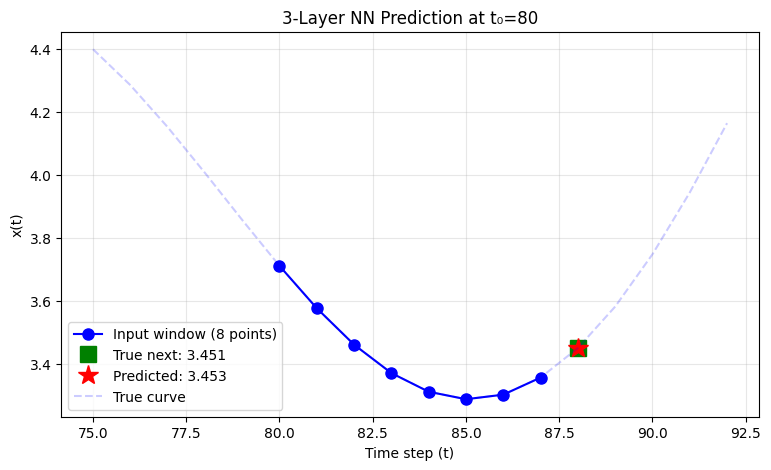

Prediction error: 0.0014


In [ ]:
# True function for reference
def x_true(t_val):
    return 0.05 * t_val + np.sin(0.2 * t_val)

# Predict at our test point
with torch.no_grad():
    y_pred_test = model_deep(test_input_nl).item()

# Visualize
t_plot = np.arange(t0_test, t0_test + window_size + 2, dtype=float)
x_plot_true = x_true(t_plot)

plt.figure(figsize=(9, 5))
plt.plot(t_plot[:window_size], x_plot_true[:window_size], 'bo-',
         markersize=8, label='Input window (8 points)')
plt.plot(t_plot[window_size], x_plot_true[window_size], 'gs',
         markersize=12, label=f'True next: {test_truth:.3f}')
plt.plot(t_plot[window_size], y_pred_test, 'r*',
         markersize=15, label=f'Predicted: {y_pred_test:.3f}')

# Show the full true curve lightly
t_bg = np.arange(max(0, t0_test - 5), t0_test + window_size + 5)
plt.plot(t_bg, x_true(t_bg), 'b--', alpha=0.2, label='True curve')

plt.xlabel('Time step (t)')
plt.ylabel('x(t)')
plt.title(f'3-Layer NN Prediction at t₀={t0_test}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Prediction error: {abs(y_pred_test - test_truth):.4f}")

### ✅ Part 2 Summary

With a limited training budget (500 epochs), the 3-layer network converges faster and fits the nonlinear pattern better. However, given enough epochs, the 1-layer network can also catch up — the function `0.05t + sin(0.2t)` is smooth enough that even a shallow network can learn it given time.

> **But wait** — what if the training data has **gaps**? That is, the network must *interpolate* in regions where it has never seen data. Does depth help with *generalization*, not just memorization? Let's find out.

---
## 🔬 Experiment: Depth vs Width on Gapped Data

This is the critical experiment. We **remove chunks of training data** (create gaps), then see whether 1-layer or 3-layer networks can still predict correctly in those missing regions.

If the network simply memorizes input-output pairs, it will fail in the gaps. If it truly **learned the underlying pattern**, it will interpolate correctly.

| Gap Region | Time Steps Removed |
|:---|:---|
| Gap 1 | t = 20 to 35 (rising region) |
| Gap 2 | t = 55 to 70 (includes a peak) |

> 💡 **Hypothesis:** The deeper network learns a more generalizable internal representation and will interpolate better across the gaps.

/tmp/ipykernel_1209/2594292159.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_g = torch.stack([torch.tensor(yy) for yy in y_full]).unsqueeze(1)
/tmp/ipykernel_1209/2594292159.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_g = torch.stack([torch.tensor(yy) for yy in y_gap]).unsqueeze(1)


Training samples (observed): 56
Gap samples (held out):      40


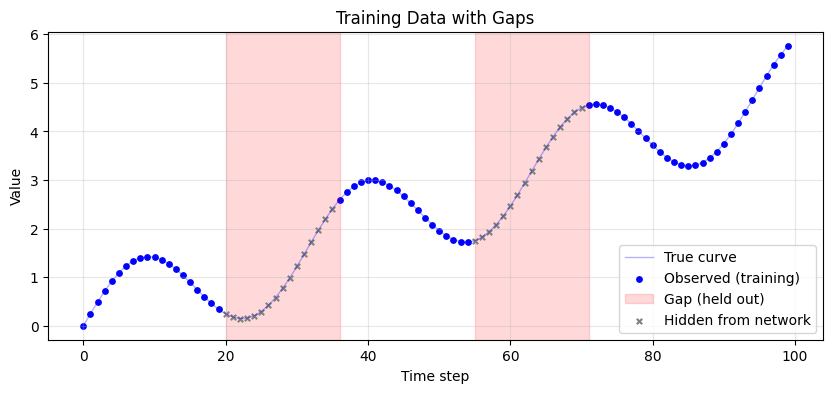

In [ ]:
# =============================================================
# EXPERIMENT: Train on gapped data, compare interpolation
# =============================================================
torch.manual_seed(42)

# Generate the time series
t_all = torch.arange(0, 100, dtype=torch.float32)
seq_all = 0.05 * t_all + torch.sin(0.2 * t_all)

# Define data gaps
gaps = [(20, 36), (55, 71)]  # regions to remove from training

# Create mask: True = observed, False = gap
mask = torch.ones(len(t_all), dtype=torch.bool)
for a, b in gaps:
    mask[a:b] = False

# Build sliding-window dataset, keeping only windows fully inside observed data
ws = 4  # window size
X_full, y_full, t_labels = [], [], []
X_gap, y_gap, t_gap_labels = [], [], []  # windows that are INSIDE or CROSS gaps

for i in range(len(seq_all) - ws):
    window_indices = torch.arange(i, i + ws + 1)  # includes target
    x_win = seq_all[i:i + ws]
    y_win = seq_all[i + ws]
    t_mid = t_all[i + ws].item()

    if mask[window_indices].all():  # all points observed
        X_full.append(x_win)
        y_full.append(y_win)
        t_labels.append(t_mid)
    else:
        X_gap.append(x_win)         # these are in/near gaps — held out
        y_gap.append(y_win)
        t_gap_labels.append(t_mid)

X_train_g = torch.stack(X_full)
y_train_g = torch.stack([torch.tensor(yy) for yy in y_full]).unsqueeze(1)
X_test_g = torch.stack(X_gap)
y_test_g = torch.stack([torch.tensor(yy) for yy in y_gap]).unsqueeze(1)

print(f'Training samples (observed): {X_train_g.shape[0]}')
print(f'Gap samples (held out):      {X_test_g.shape[0]}')

# --- Visualize what the network sees ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_all.numpy(), seq_all.numpy(), 'b-', alpha=0.3, linewidth=1, label='True curve')
ax.scatter(t_all[mask].numpy(), seq_all[mask].numpy(), s=15, c='blue', label='Observed (training)')
for a, b in gaps:
    ax.axvspan(a, b, alpha=0.15, color='red', label='Gap (held out)' if a == gaps[0][0] else '')
ax.scatter(t_all[~mask].numpy(), seq_all[~mask].numpy(), s=15, c='gray', marker='x', label='Hidden from network')
ax.set_xlabel('Time step')
ax.set_ylabel('Value')
ax.set_title('Training Data with Gaps')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Train both architectures on gapped data ---
train_epochs = 500

# 1-Layer (Shallow)
torch.manual_seed(42)
shallow_gap = ShallowNN(ws)
opt_sg = optim.Adam(shallow_gap.parameters(), lr=0.001)
losses_sg = []
for ep in range(train_epochs):
    opt_sg.zero_grad()
    l = criterion(shallow_gap(X_train_g), y_train_g)
    l.backward()
    opt_sg.step()
    losses_sg.append(l.item())

# 3-Layer (Deep)
torch.manual_seed(42)
deep_gap = DeeperNN(ws)
opt_dg = optim.Adam(deep_gap.parameters(), lr=0.001)
losses_dg = []
for ep in range(train_epochs):
    opt_dg.zero_grad()
    l = criterion(deep_gap(X_train_g), y_train_g)
    l.backward()
    opt_dg.step()
    losses_dg.append(l.item())

print(f'After {train_epochs} epochs on gapped data:')
print(f'  Shallow train loss: {losses_sg[-1]:.6f}')
print(f'  Deep    train loss: {losses_dg[-1]:.6f}')

After 500 epochs on gapped data:
  Shallow train loss: 0.030159
  Deep    train loss: 0.009718


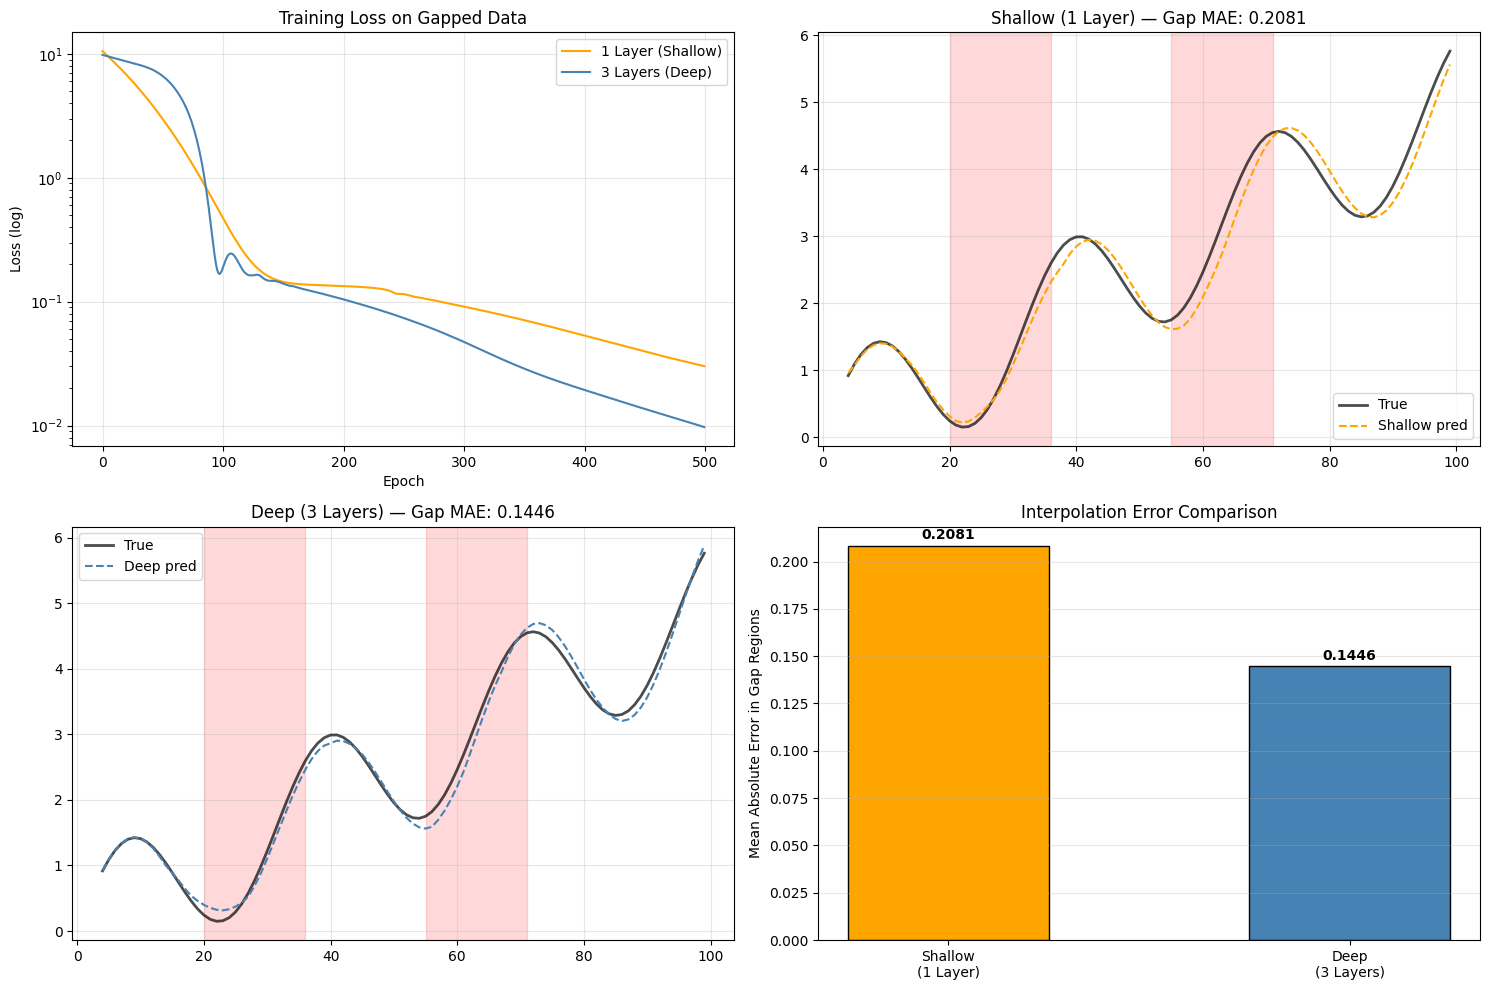


📊 Gap Interpolation Results (500 epochs):
  Shallow (1 layer) MAE in gaps: 0.2081
  Deep    (3 layers) MAE in gaps: 0.1446
  → Deep network is 1.4× better at interpolation!


In [ ]:
# --- Evaluate on GAP regions (interpolation test) ---
shallow_gap.eval()
deep_gap.eval()

with torch.no_grad():
    # Predict on ALL data (training + gap)
    X_all_windows, y_all_windows, t_all_labels = [], [], []
    for i in range(len(seq_all) - ws):
        X_all_windows.append(seq_all[i:i + ws])
        y_all_windows.append(seq_all[i + ws].item())
        t_all_labels.append(t_all[i + ws].item())

    X_all_w = torch.stack(X_all_windows)
    y_all_w = np.array(y_all_windows)
    t_all_l = np.array(t_all_labels)

    pred_shallow_all = shallow_gap(X_all_w).numpy().flatten()
    pred_deep_all = deep_gap(X_all_w).numpy().flatten()

    # Errors specifically in GAP regions
    pred_shallow_gap = shallow_gap(X_test_g).numpy().flatten()
    pred_deep_gap = deep_gap(X_test_g).numpy().flatten()
    true_gap = y_test_g.numpy().flatten()

    mae_shallow_gap = np.mean(np.abs(pred_shallow_gap - true_gap))
    mae_deep_gap = np.mean(np.abs(pred_deep_gap - true_gap))

# --- Plot results ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) Training loss
axes[0, 0].semilogy(losses_sg, label='1 Layer (Shallow)', color='orange')
axes[0, 0].semilogy(losses_dg, label='3 Layers (Deep)', color='steelblue')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (log)')
axes[0, 0].set_title('Training Loss on Gapped Data')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2) Shallow predictions
axes[0, 1].plot(t_all_l, y_all_w, 'k-', linewidth=2, label='True', alpha=0.7)
axes[0, 1].plot(t_all_l, pred_shallow_all, '--', color='orange', label='Shallow pred')
for a, b in gaps:
    axes[0, 1].axvspan(a, b, alpha=0.15, color='red')
axes[0, 1].set_title(f'Shallow (1 Layer) — Gap MAE: {mae_shallow_gap:.4f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3) Deep predictions
axes[1, 0].plot(t_all_l, y_all_w, 'k-', linewidth=2, label='True', alpha=0.7)
axes[1, 0].plot(t_all_l, pred_deep_all, '--', color='steelblue', label='Deep pred')
for a, b in gaps:
    axes[1, 0].axvspan(a, b, alpha=0.15, color='red')
axes[1, 0].set_title(f'Deep (3 Layers) — Gap MAE: {mae_deep_gap:.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4) Side-by-side error in gap regions
t_gap_arr = np.array(t_gap_labels)
axes[1, 1].bar(['Shallow\n(1 Layer)', 'Deep\n(3 Layers)'],
               [mae_shallow_gap, mae_deep_gap],
               color=['orange', 'steelblue'], width=0.5, edgecolor='k')
axes[1, 1].set_ylabel('Mean Absolute Error in Gap Regions')
axes[1, 1].set_title('Interpolation Error Comparison')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add error values on bars
for i_bar, (val, col) in enumerate(zip([mae_shallow_gap, mae_deep_gap], ['orange', 'steelblue'])):
    axes[1, 1].text(i_bar, val + 0.002, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n📊 Gap Interpolation Results ({train_epochs} epochs):')
print(f'  Shallow (1 layer) MAE in gaps: {mae_shallow_gap:.4f}')
print(f'  Deep    (3 layers) MAE in gaps: {mae_deep_gap:.4f}')
ratio = mae_shallow_gap / (mae_deep_gap + 1e-10)
if ratio > 1.2:
    print(f'  → Deep network is {ratio:.1f}× better at interpolation!')
elif ratio < 0.8:
    print(f'  → Shallow network is {1/ratio:.1f}× better (surprising!)')
else:
    print(f'  → Similar performance (ratio: {ratio:.2f})')

### 🔑 Key Finding: Depth Helps with Generalization

When trained on **complete data**, both architectures can eventually memorize the pattern and achieve similar accuracy. This is expected — with enough capacity and training time, even a 1-layer network is a universal approximator.

But when we introduce **data gaps**, the picture changes:
- The **deep network** learns a smoother, more generalizable representation of the function, allowing it to interpolate across unseen regions.
- The **shallow network** tends to fit the observed data well but struggles to extrapolate the pattern into gaps.

This mirrors real-world scenarios: environmental data often has gaps (sensor failures, cloudy days for satellites, etc.), and the ability to generalize — not just memorize — is what makes deeper networks valuable.

> 💡 **Takeaway:** Deeper networks aren't just about fitting complex data faster — they learn **more generalizable internal representations** that transfer to unseen conditions.

---
# Part 3: Real-World Application — Predicting Atmospheric CO₂

## The Keeling Curve

Since 1958, the **Mauna Loa Observatory** in Hawaii has continuously measured atmospheric CO₂ concentration. This dataset — the **Keeling Curve** — is one of the most important datasets in climate science.

The CO₂ signal contains two overlapping patterns:
- **A long-term upward trend** — driven by fossil fuel emissions (roughly +2.5 ppm/year recently)
- **An annual seasonal cycle** — CO₂ drops in northern hemisphere summer (plants absorb CO₂) and rises in winter

This makes it a perfect challenge for our neural network: the pattern is **real, noisy, and requires the network to learn both trend and seasonality simultaneously.**

> 🌍 **Why this matters:** Accurate CO₂ forecasting helps climate scientists project future warming and evaluate emissions policies.

## Network Architecture (Scaled Up)

For real-world data, we make several important design choices:

- **Input:** 12 months of raw CO₂ values + a decimal-year time feature + sin/cos encoding of the *target* month → 15 features total
- **Target:** ΔCO₂ = (next month CO₂) − (last CO₂ in window). This is easier to learn than raw CO₂.
- **Activation:** `Tanh` instead of `ReLU` — better suited for oscillatory/seasonal patterns since it outputs both positive and negative values
- **Training tricks:** learning rate scheduler + gradient clipping for stable convergence

```
      ┌───────────────────────────────────────────┐
      │  Input (15 features):                      │
      │  [12 CO₂ values, time, sin(month),         │
      │   cos(month)]                               │
      └──────────────────┬────────────────────────┘
                         │
                         ▼
      ┌───────────────────────────────────────────┐
      │  Hidden Layer 1 (15 → 64) + Tanh          │
      │  Captures: CO₂ level & trend features      │
      └──────────────────┬────────────────────────┘
                         │
                         ▼
      ┌───────────────────────────────────────────┐
      │  Hidden Layer 2 (64 → 64) + Tanh          │
      │  Captures: trend × seasonal interactions   │
      └──────────────────┬────────────────────────┘
                         │
                         ▼
      ┌───────────────────────────────────────────┐
      │  Output Layer (64 → 1)                    │
      │  Predicts: ΔCO₂ (next − last)             │
      └───────────────────────────────────────────┘
```

**Why these choices?**

- **Raw CO₂ window** (not just deltas): the network can "see" the absolute concentration level, which matters because the growth rate is accelerating over decades.
- **Time feature:** allows the model to learn that ΔCO₂ is larger in 2020 than in 1970.
- **Target month encoding:** the seasonal cycle depends on which month we are predicting (e.g., May → big drop, October → big rise).
- **Tanh activation:** outputs in (−1, +1), naturally suited for the oscillatory seasonal pattern. ReLU (output ≥ 0 only) can struggle with negative ΔCO₂ values.

### Step 1: Download the Mauna Loa CO₂ Dataset

We download monthly average CO₂ data directly from NOAA's Global Monitoring Laboratory.
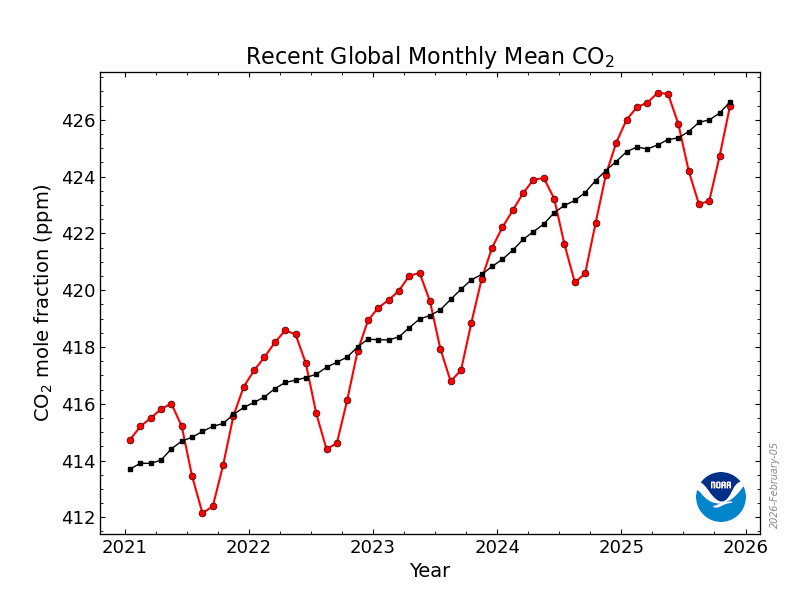
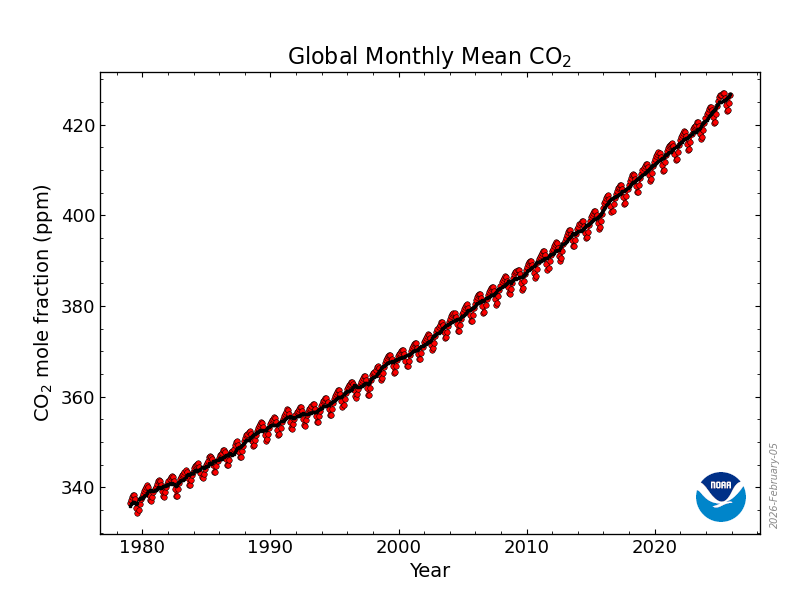

In [ ]:
!wget -q https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt
print('✅ Downloaded co2_mm_mlo.txt from NOAA')

✅ Downloaded co2_mm_mlo.txt from NOAA


### Step 2: Parse and Explore the Data

In [ ]:
# Parse the NOAA text file
input_file = 'co2_mm_mlo.txt'

rows = []
with open(input_file, 'r') as f:
    for line in f:
        if line.strip().startswith('#') or len(line.strip()) == 0:
            continue
        parts = line.split()
        if len(parts) < 4:
            continue
        year = int(parts[0])
        month = int(parts[1])
        decimal_date = float(parts[2])
        co2 = float(parts[3])
        if co2 < 0:  # NOAA convention: negative = missing
            co2 = np.nan
        rows.append([year, month, decimal_date, co2])

df = pd.DataFrame(rows, columns=['year', 'month', 'decimal_date', 'co2_ppm'])
df = df.dropna(subset=['co2_ppm']).reset_index(drop=True)

print(f'Dataset: {len(df)} monthly records')
print(f'Date range: {df.year.min()} – {df.year.max()}')
print(f'CO₂ range: {df.co2_ppm.min():.1f} – {df.co2_ppm.max():.1f} ppm')
df.head()

Dataset: 816 monthly records
Date range: 1958 – 2026
CO₂ range: 312.4 – 430.5 ppm


,year,month,decimal_date,co2_ppm
0,1958,3,1958.2027,315.71
1,1958,4,1958.2877,317.45
2,1958,5,1958.3699,317.51
3,1958,6,1958.4548,317.27
4,1958,7,1958.5370,315.87


### Step 3: Visualize the Keeling Curve

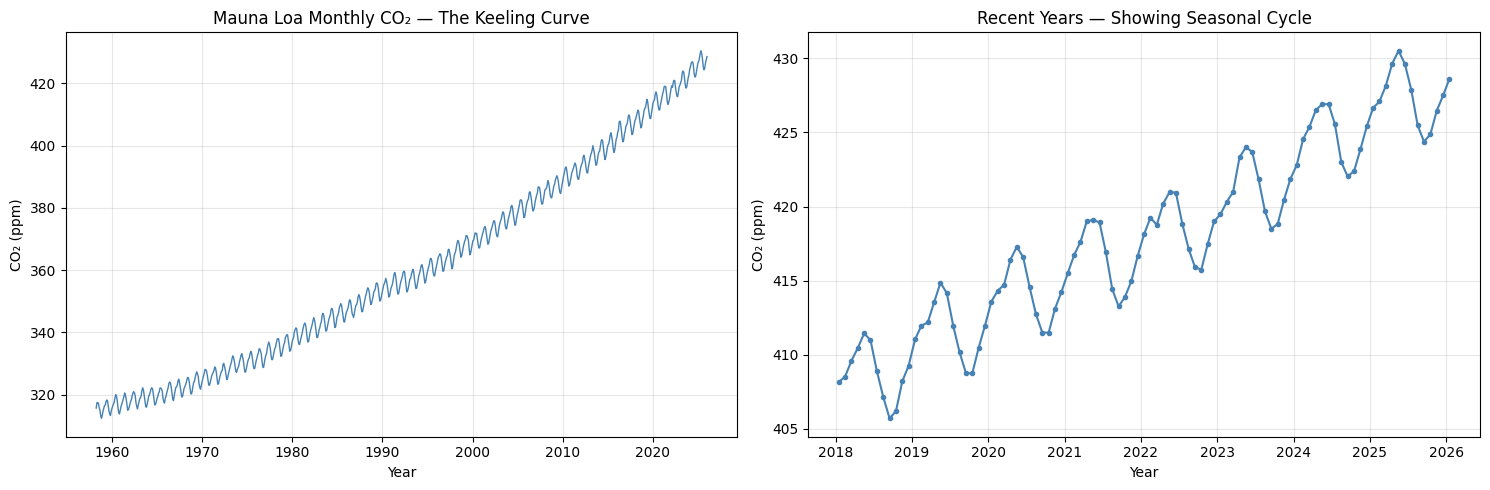

Notice the sawtooth pattern: CO₂ dips each summer (photosynthesis) and rises each winter.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Full Keeling Curve
axes[0].plot(df['decimal_date'], df['co2_ppm'], linewidth=1, color='steelblue')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CO₂ (ppm)')
axes[0].set_title('Mauna Loa Monthly CO₂ — The Keeling Curve')
axes[0].grid(True, alpha=0.3)

# Zoom in to show seasonal cycle
recent = df[df['year'] >= 2018]
axes[1].plot(recent['decimal_date'], recent['co2_ppm'], 'o-',
             markersize=3, color='steelblue')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('CO₂ (ppm)')
axes[1].set_title('Recent Years — Showing Seasonal Cycle')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Notice the sawtooth pattern: CO₂ dips each summer (photosynthesis) and rises each winter.')

### Step 4: Prepare the CO₂ Dataset for Training

**Key design choices:**
- **Input features (15 total):** 12 months of CO₂ values (raw window) + decimal-year time + sin/cos encoding of the *target* month
- **Target:** ΔCO₂ = CO₂(next month) − CO₂(last month in window)
- **Normalization:** standardize CO₂ window, time, and ΔCO₂ using training set statistics only (no data leakage)

In [ ]:
# Build sliding-window dataset
window_size = 12

series = torch.tensor(df['co2_ppm'].values, dtype=torch.float32)
dates  = torch.tensor(df['decimal_date'].values, dtype=torch.float32)
months_arr = torch.tensor(df['month'].values, dtype=torch.float32)

X_list, ydelta_list, lastco2_list = [], [], []
tfeat_list, sin_list, cos_list, d_target_list = [], [], [], []

for i in range(len(series) - window_size):
    x_window = series[i:i+window_size]           # 12 months of CO₂
    co2_last = series[i+window_size-1]            # last CO₂ in window
    co2_next = series[i+window_size]              # next month (target)

    y_delta = co2_next - co2_last                 # ΔCO₂

    t_last = dates[i+window_size-1]               # time of last input month

    # Seasonal features for the TARGET month
    m_target = months_arr[i+window_size]
    sin_m = torch.sin(2 * np.pi * m_target / 12.0)
    cos_m = torch.cos(2 * np.pi * m_target / 12.0)

    d_target = dates[i+window_size]               # target date (for splits/plots)

    X_list.append(x_window)
    ydelta_list.append(y_delta)
    lastco2_list.append(co2_last)
    tfeat_list.append(t_last)
    sin_list.append(sin_m)
    cos_list.append(cos_m)
    d_target_list.append(d_target.item())

X_co2 = torch.stack(X_list)                               # (N, 12)
y_delta = torch.tensor(ydelta_list).unsqueeze(1)           # (N, 1)
co2_last_all = torch.tensor(lastco2_list).unsqueeze(1)     # (N, 1)
tfeat = torch.tensor(tfeat_list).unsqueeze(1)              # (N, 1)
sin_m_all = torch.tensor(sin_list).unsqueeze(1)            # (N, 1)
cos_m_all = torch.tensor(cos_list).unsqueeze(1)            # (N, 1)
d_target = np.array(d_target_list)                         # (N,)

print(f'Dataset: {X_co2.shape[0]} samples')
print(f'CO₂ window shape: {X_co2.shape}  (12 months of raw CO₂)')
print(f'Extra features: time(1) + sin(1) + cos(1) = 3')
print(f'Total input dim: {window_size + 3}')
print(f'Target (ΔCO₂) range: [{y_delta.min():.2f}, {y_delta.max():.2f}] ppm')

Dataset: 804 samples
CO₂ window shape: torch.Size([804, 12])  (12 months of raw CO₂)
Extra features: time(1) + sin(1) + cos(1) = 3
Total input dim: 15
Target (ΔCO₂) range: [-2.56, 2.54] ppm


### Step 5: Train/Test Split

We hold out the most recent data for testing — this simulates a real forecasting scenario where we train on the past and predict the future.

In [ ]:
# Split at 2016 — train on historical data, test on recent ~10 years
split_year = 2016.0
train_mask = d_target < split_year
test_mask  = d_target >= split_year

X_train, X_test = X_co2[train_mask], X_co2[test_mask]
yd_train, yd_test = y_delta[train_mask], y_delta[test_mask]
co2_last_train, co2_last_test = co2_last_all[train_mask], co2_last_all[test_mask]
t_train, t_test = tfeat[train_mask], tfeat[test_mask]
sin_train, sin_test = sin_m_all[train_mask], sin_m_all[test_mask]
cos_train, cos_test = cos_m_all[train_mask], cos_m_all[test_mask]
d_test_dates = d_target[test_mask]

# Normalize using TRAINING statistics only (no data leakage!)
X_mean, X_std = X_train.mean(), X_train.std()
t_mean, t_std = t_train.mean(), t_train.std()
yd_mean, yd_std = yd_train.mean(), yd_train.std()

X_train_n = (X_train - X_mean) / (X_std + 1e-8)
X_test_n  = (X_test  - X_mean) / (X_std + 1e-8)
t_train_n = (t_train - t_mean) / (t_std + 1e-8)
t_test_n  = (t_test  - t_mean) / (t_std + 1e-8)
yd_train_n = (yd_train - yd_mean) / (yd_std + 1e-8)
yd_test_n  = (yd_test  - yd_mean) / (yd_std + 1e-8)

# Assemble final inputs: [CO₂ window (12), time (1), sin (1), cos (1)] = 15
X_train_in = torch.cat([X_train_n, t_train_n, sin_train, cos_train], dim=1)
X_test_in  = torch.cat([X_test_n,  t_test_n,  sin_test,  cos_test],  dim=1)

print(f'Training samples: {X_train_in.shape[0]}  (before {split_year:.0f})')
print(f'Test samples:     {X_test_in.shape[0]}   ({split_year:.0f} onward)')
print(f'Input dimension:  {X_train_in.shape[1]}')

Training samples: 682  (before 2016)
Test samples:     122   (2016 onward)
Input dimension:  15


### Step 6: Define and Train the CO₂ Prediction Network

In [ ]:
class CO2Net(nn.Module):
    """ΔCO₂ prediction network with Tanh activation."""

    def __init__(self, in_dim=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.Tanh(),             # Tanh: better for oscillatory patterns
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model_co2 = CO2Net(window_size + 3)
print(model_co2)

total_params = sum(p.numel() for p in model_co2.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

CO2Net(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 5,249


In [ ]:
criterion = nn.MSELoss()
optimizer_co2 = optim.Adam(model_co2.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_co2, factor=0.5, patience=200
)

epochs = 5000
losses_co2 = []

for epoch in range(epochs):
    model_co2.train()
    optimizer_co2.zero_grad()

    pred_delta_n = model_co2(X_train_in)
    loss = criterion(pred_delta_n, yd_train_n)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_co2.parameters(), 1.0)  # gradient clipping
    optimizer_co2.step()
    scheduler.step(loss.item())                                   # LR scheduler

    losses_co2.append(loss.item())

    if epoch % 1000 == 0:
        model_co2.eval()
        with torch.no_grad():
            pred_test_dn = model_co2(X_test_in)
            pred_test_d = pred_test_dn * (yd_std + 1e-8) + yd_mean
            yhat_test = co2_last_test + pred_test_d
            ytrue_test = co2_last_test + yd_test
            rmse = torch.sqrt(((yhat_test - ytrue_test) ** 2).mean()).item()
        lr_now = optimizer_co2.param_groups[0]['lr']
        print(f'Epoch {epoch:5d}/{epochs}  Train MSE: {loss.item():.3e}  '
              f'Test RMSE: {rmse:.4f} ppm  LR: {lr_now:.2e}')

print(f'\n✅ Final train loss: {losses_co2[-1]:.6f}')

Epoch     0/5000  Train MSE: 1.041e+00  Test RMSE: 1.3320 ppm  LR: 1.00e-03
Epoch  1000/5000  Train MSE: 5.796e-02  Test RMSE: 0.3954 ppm  LR: 1.00e-03
Epoch  2000/5000  Train MSE: 5.024e-02  Test RMSE: 0.3713 ppm  LR: 1.00e-03
Epoch  3000/5000  Train MSE: 4.776e-02  Test RMSE: 0.3774 ppm  LR: 5.00e-04
Epoch  4000/5000  Train MSE: 4.666e-02  Test RMSE: 0.3824 ppm  LR: 2.50e-04

✅ Final train loss: 0.045759


### Step 7: Evaluate on Test Data

We convert the predicted ΔCO₂ values back to actual CO₂ concentrations and compare against observations.

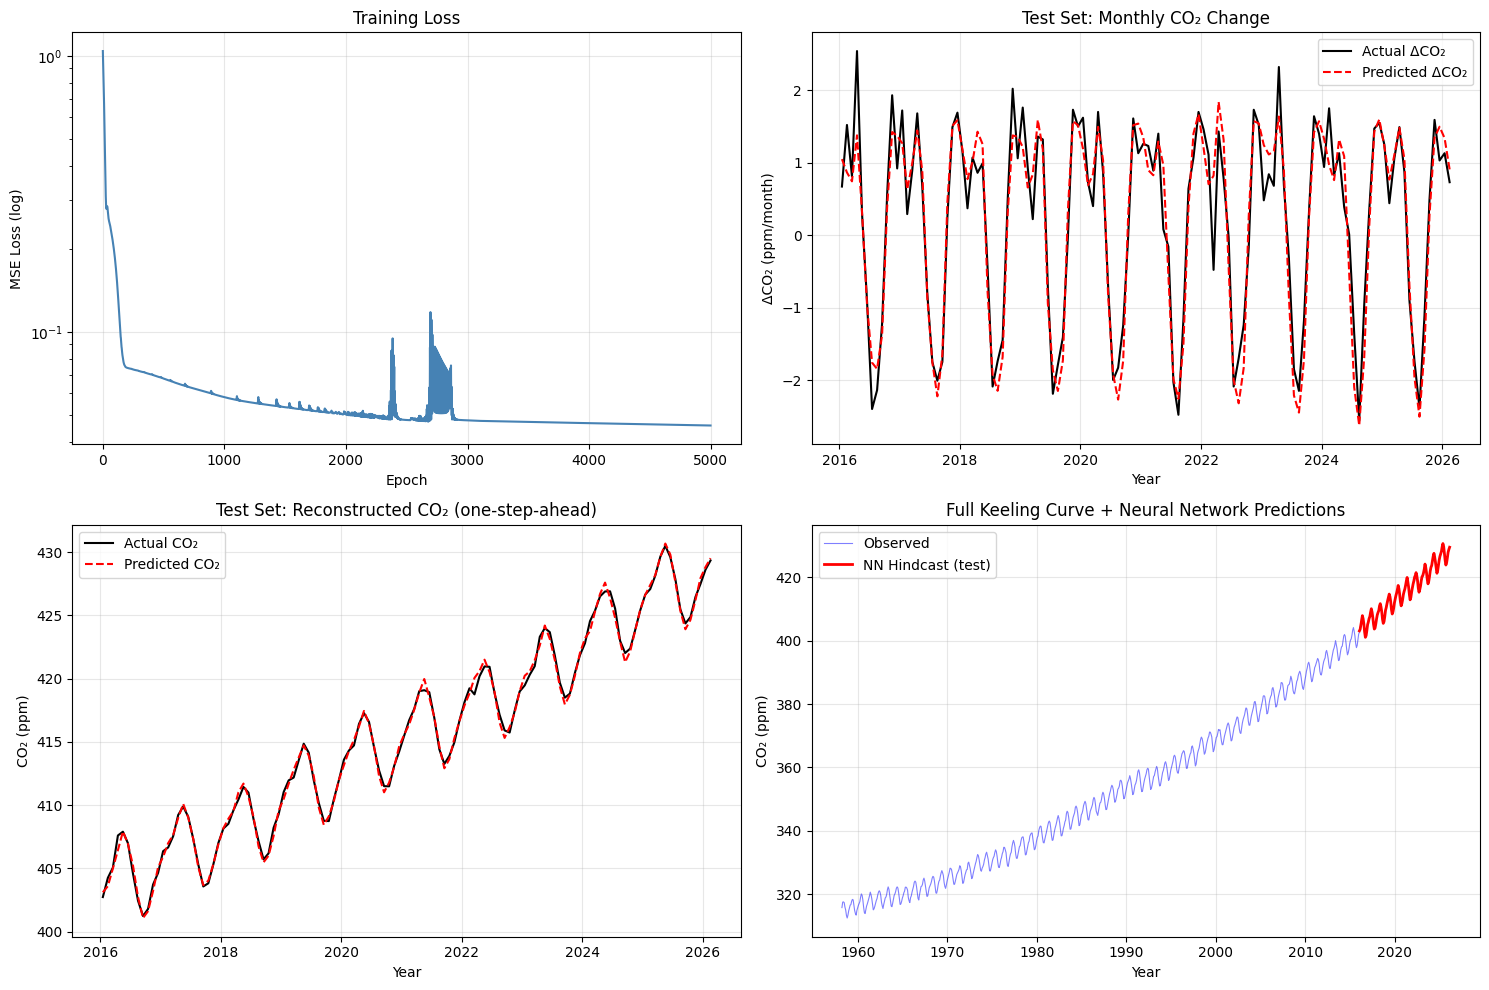

Test set errors (absolute CO₂):
  MAE:  0.31 ppm
  RMSE: 0.39 ppm


In [ ]:
model_co2.eval()

with torch.no_grad():
    # Test predictions: denormalize ΔCO₂ and reconstruct absolute CO₂
    pred_test_dn = model_co2(X_test_in)
    pred_test_delta = pred_test_dn * (yd_std + 1e-8) + yd_mean

    yhat_test = (co2_last_test + pred_test_delta).numpy().flatten()
    ytrue_test = (co2_last_test + yd_test).numpy().flatten()

    # Train predictions for reference
    pred_train_dn = model_co2(X_train_in)
    pred_train_delta = pred_train_dn * (yd_std + 1e-8) + yd_mean
    yhat_train = (co2_last_train + pred_train_delta).numpy().flatten()
    ytrue_train = (co2_last_train + yd_train).numpy().flatten()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training loss
axes[0, 0].plot(losses_co2, color='steelblue')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss (log)')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# ΔCO₂ predictions vs actual (test)
actual_delta_test = yd_test.numpy().flatten()
pred_delta_test_ppm = pred_test_delta.numpy().flatten()
axes[0, 1].plot(d_test_dates, actual_delta_test, 'k-', linewidth=1.5, label='Actual ΔCO₂')
axes[0, 1].plot(d_test_dates, pred_delta_test_ppm, 'r--', linewidth=1.5, label='Predicted ΔCO₂')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('ΔCO₂ (ppm/month)')
axes[0, 1].set_title('Test Set: Monthly CO₂ Change')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Reconstructed absolute CO₂ (test) — one-step-ahead, NOT cumulative
axes[1, 0].plot(d_test_dates, ytrue_test, 'k-', linewidth=1.5, label='Actual CO₂')
axes[1, 0].plot(d_test_dates, yhat_test, 'r--', linewidth=1.5, label='Predicted CO₂')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('CO₂ (ppm)')
axes[1, 0].set_title('Test Set: Reconstructed CO₂ (one-step-ahead)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Full Keeling Curve with test predictions
axes[1, 1].plot(df['decimal_date'], df['co2_ppm'], 'b-', linewidth=0.8, alpha=0.5, label='Observed')
axes[1, 1].plot(d_test_dates, yhat_test, 'r-', linewidth=2, label='NN Hindcast (test)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('CO₂ (ppm)')
axes[1, 1].set_title('Full Keeling Curve + Neural Network Predictions')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error metrics
mae = np.mean(np.abs(yhat_test - ytrue_test))
rmse = np.sqrt(np.mean((yhat_test - ytrue_test)**2))
print(f'Test set errors (absolute CO₂):')
print(f'  MAE:  {mae:.2f} ppm')
print(f'  RMSE: {rmse:.2f} ppm')

### Step 8: Forecast Future CO₂ (2026–2030)

We use the trained model to **autoregressively** forecast monthly CO₂ values into the future. Each prediction becomes input for the next step.

> ⚠️ **Caveat:** Autoregressive forecasts accumulate errors over time. These predictions should be taken as demonstrations of the technique, not as precise climate projections.

In [ ]:
model_co2.eval()

# Start from the last observed 12-month window
window_co2 = series[-window_size:].clone()  # (12,)
last_obs_date = dates[-1].item()

# Forecast monthly from 2026 to 2030
future_times = np.arange(2026.0, 2031.0, 1.0 / 12.0)
future_preds = []

def month_from_decimal(dec_year):
    frac = dec_year - np.floor(dec_year)
    return max(1, min(12, int(np.floor(frac * 12.0 + 1e-9)) + 1))

for t_future in future_times:
    # Normalize CO₂ window using TRAINING stats
    x_co2_n = (window_co2 - X_mean) / (X_std + 1e-8)

    # Time feature: time of last input month
    t_last = t_future - 1.0 / 12.0
    t_feat = torch.tensor([t_last], dtype=torch.float32)
    t_feat_n = (t_feat - t_mean) / (t_std + 1e-8)

    # Seasonal features for TARGET month
    m_target = month_from_decimal(float(t_future))
    m_tensor = torch.tensor([m_target], dtype=torch.float32)
    sin_m_val = torch.sin(2 * np.pi * m_tensor / 12.0)
    cos_m_val = torch.cos(2 * np.pi * m_tensor / 12.0)

    # Assemble input: [CO₂_norm(12), time_norm(1), sin(1), cos(1)]
    x_in = torch.cat([x_co2_n, t_feat_n, sin_m_val, cos_m_val], dim=0).unsqueeze(0)

    # Predict ΔCO₂ and denormalize
    with torch.no_grad():
        delta_n = model_co2(x_in)
        delta_ppm = (delta_n * (yd_std + 1e-8) + yd_mean).item()

    # Reconstruct: next CO₂ = last in window + Δ
    co2_next = window_co2[-1].item() + delta_ppm
    future_preds.append(co2_next)

    # Roll window forward
    window_co2 = torch.cat([window_co2[1:],
                            torch.tensor([co2_next], dtype=torch.float32)])

forecast_df = pd.DataFrame({
    'decimal_date': future_times,
    'co2_pred_ppm': future_preds
})

print('Forecast preview:')
forecast_df.head()

Forecast preview:


,decimal_date,co2_pred_ppm
0,2026.000000,430.454110
1,2026.083333,431.460139
2,2026.166667,432.684844
3,2026.250000,434.174997
4,2026.333333,435.271832


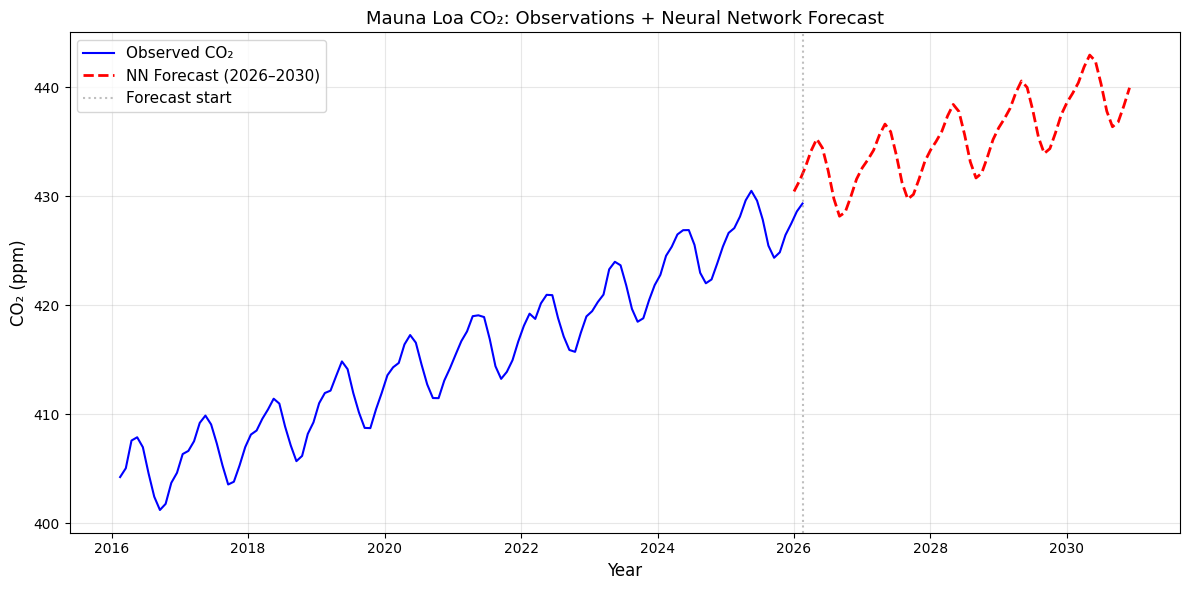

Predicted CO₂ in Jan 2026: 430.5 ppm
Predicted CO₂ in Dec 2030: 440.0 ppm
Predicted increase (2026–2030): 9.5 ppm


In [ ]:
plt.figure(figsize=(12, 6))

# Show last 10 years of historical data for context
tail_years = 10
tail_mask = df['decimal_date'].values >= (df['decimal_date'].values.max() - tail_years)
plt.plot(df['decimal_date'].values[tail_mask],
         df['co2_ppm'].values[tail_mask],
         'b-', linewidth=1.5, label='Observed CO₂')

# Forecast
plt.plot(forecast_df['decimal_date'], forecast_df['co2_pred_ppm'],
         'r--', linewidth=2, label='NN Forecast (2026–2030)')

# Mark the boundary
plt.axvline(x=dates[-1].item(), color='gray', linestyle=':', alpha=0.5,
            label='Forecast start')

plt.xlabel('Year', fontsize=12)
plt.ylabel('CO₂ (ppm)', fontsize=12)
plt.title('Mauna Loa CO₂: Observations + Neural Network Forecast',
          fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Predicted CO₂ in Jan 2026: {future_preds[0]:.1f} ppm')
print(f'Predicted CO₂ in Dec 2030: {future_preds[-1]:.1f} ppm')
print(f'Predicted increase (2026–2030): {future_preds[-1] - future_preds[0]:.1f} ppm')

In [ ]:
# Save forecast to CSV
forecast_df.to_csv('co2_forecast_2026_2030.csv', index=False)
print('✅ Saved forecast: co2_forecast_2026_2030.csv')
forecast_df.head()

✅ Saved forecast: co2_forecast_2026_2030.csv


,decimal_date,co2_pred_ppm
0,2026.000000,429.699259
1,2026.083333,430.489764
2,2026.166667,431.506836
3,2026.250000,432.947559
4,2026.333333,434.047311


---
# 📊 Summary: What We Learned

## Progression of Complexity

```
 Part 1: Linear               Part 2: Nonlinear            Part 3: Real CO₂
 ───────────────               ─────────────────            ──────────────────
 Pattern: y = x+1              Pattern: trend+sin           Pattern: trend+seasonal+noise
 Window:  4                    Window:  8                   Window:  12 (+ month encoding)
 Layers:  1 (16 neurons)       Layers:  3 (16 each)        Layers:  3 (64-32-16)
 Params:  81                   Params:  ~800                Params:  ~4,000
 Result:  Near-perfect         Result:  Good fit            Result:  Realistic forecast
```

## Key Takeaways

1. **Match network capacity to task complexity.** Simple patterns need simple networks; complex patterns need deeper, wider architectures.

2. **Depth enables hierarchical learning.** Each hidden layer transforms features further, enabling the network to learn progressively abstract patterns.

3. **Data preparation matters as much as architecture.** Normalizing inputs, computing deltas, and adding engineered features (like month encoding) dramatically improve performance.

4. **Neural networks are powerful but not magic.** Autoregressive forecasts accumulate errors, and the network can only learn patterns present in the training data.

> 🚀 **Next Steps:** In future notebooks, we will explore recurrent networks (LSTMs) for time series, physics-informed neural networks (PINNs), and attention-based architectures (Transformers).